In [4]:
import pandas as pd
import numpy as np

In [5]:
data = pd.read_csv('/Users/songsooyeoun/Desktop/git_test/streamlit/seoul_housing/data/seoul_real_estate.csv')
data

,RCPT_YR,CGG_CD,CGG_NM,STDG_CD,STDG_NM,LOTNO_SE,LOTNO_SE_NM,MNO,SNO,BLDG_NM,...,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE,OPBIZ_RESTAGNT_SGG_NM
0,2025,11230,동대문구,10500,답십리동,1.0,대지,530.0,15.0,현대썬앤빌청계,...,12150,14.820,0.0000,9.0,NaN,NaN,2016.0,아파트,중개거래,서울 동대문구
1,2025,11650,서초구,10600,잠원동,1.0,대지,27.0,2.0,멀버리힐스,...,42000,21.863,32.9893,8.0,NaN,NaN,2022.0,오피스텔,중개거래,서울 서초구
2,2025,11530,구로구,10300,가리봉동,1.0,대지,137.0,4.0,삼부르네상스파크빌,...,40000,82.775,110.3780,7.0,NaN,NaN,2006.0,오피스텔,직거래,NaN
3,2025,11500,강서구,10700,외발산동,1.0,대지,216.0,37.0,가온빌,...,15000,23.730,20.0000,5.0,NaN,NaN,2016.0,연립다세대,직거래,NaN
4,2025,11620,관악구,10100,봉천동,1.0,대지,180.0,348.0,백조아트빌라,...,15000,57.950,25.0000,-1.0,NaN,NaN,1996.0,연립다세대,직거래,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22995,2025,11380,은평구,10300,불광동,1.0,대지,484.0,63.0,연신내역트리플라101동,...,30800,25.430,0.0000,5.0,NaN,NaN,2021.0,아파트,직거래,NaN
22996,2025,11680,강남구,10100,역삼동,1.0,대지,719.0,24.0,역삼역센트럴푸르지오시티,...,21000,17.573,28.0423,17.0,NaN,NaN,2019.0,오피스텔,중개거래,서울 강남구
22997,2025,11650,서초구,10300,우면동,1.0,대지,788.0,0.0,엘에이치서초4단지,...,97000,51.890,0.0000,1.0,NaN,NaN,2013.0,아파트,중개거래,서울 서초구
22998,2025,11230,동대문구,10200,용두동,1.0,대지,39.0,808.0,엘림,...,21000,26.330,18.0000,5.0,NaN,NaN,2016.0,연립다세대,중개거래,경기 파주시


In [10]:
data.select_dtypes(include=['object']).info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23000 entries, 0 to 22999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   CGG_NM                 23000 non-null  object
 1   STDG_NM                23000 non-null  object
 2   LOTNO_SE_NM            22417 non-null  object
 3   BLDG_NM                22417 non-null  object
 4   CTRT_DAY               23000 non-null  object
 5   RGHT_SE                280 non-null    object
 6   BLDG_USG               23000 non-null  object
 7   DCLR_SE                23000 non-null  object
 8   OPBIZ_RESTAGNT_SGG_NM  20036 non-null  object
dtypes: object(9)
memory usage: 1.6+ MB


In [12]:
data.select_dtypes(include=['object']).head()

,CGG_NM,STDG_NM,LOTNO_SE_NM,BLDG_NM,CTRT_DAY,RGHT_SE,BLDG_USG,DCLR_SE,OPBIZ_RESTAGNT_SGG_NM
0,동대문구,답십리동,대지,현대썬앤빌청계,2025-03-28,NaN,아파트,중개거래,서울 동대문구
1,서초구,잠원동,대지,멀버리힐스,2025-03-28,NaN,오피스텔,중개거래,서울 서초구
2,구로구,가리봉동,대지,삼부르네상스파크빌,2025-03-28,NaN,오피스텔,직거래,NaN
3,강서구,외발산동,대지,가온빌,2025-03-28,NaN,연립다세대,직거래,NaN
4,관악구,봉천동,대지,백조아트빌라,2025-03-28,NaN,연립다세대,직거래,NaN


In [20]:
import pandas as pd

# Assuming your DataFrame is 'data'
# Split the 'OPBIZ_RESTAGNT_SGG_NM' column to extract the district (e.g., '도봉구' from '서울시 도봉구')
data['district_in_opbiz'] = data['OPBIZ_RESTAGNT_SGG_NM'].str.split().str[1]

# Compare the 'district_in_opbiz' with 'CGG_NM'
mismatch = data[data['CGG_NM'] != data['district_in_opbiz']]

# Display the mismatched rows
display(mismatch[['CGG_CD', 'CGG_NM', 'district_in_opbiz']])


,CGG_CD,CGG_NM,district_in_opbiz
2,11530,구로구,NaN
3,11500,강서구,NaN
4,11620,관악구,NaN
7,11740,강동구,NaN
8,11215,광진구,NaN
...,...,...,...
22986,11350,노원구,"노원구,"
22990,11740,강동구,"강동구,"
22991,11740,강동구,"달서구,"
22995,11380,은평구,NaN


In [7]:
data["CTRT_DAY"] = pd.to_datetime(data["CTRT_DAY"].astype(str), format="%Y-%m-%d")
data["month"] = data["CTRT_DAY"].dt.month
data["month"].unique()

array([3, 2, 1], dtype=int32)

In [8]:
print(data["CTRT_DAY"].min())
print(data["CTRT_DAY"].max())

2025-01-04 00:00:00
2025-03-28 00:00:00


In [30]:
filtered_month = jan_data.dropna(subset=['THING_AMT'])  
min_price = filtered_month['THING_AMT'].min()
max_price = filtered_month['THING_AMT'].max()

print(min_price)
print(max_price)

3000
1090000


In [11]:
print(data["CTRT_DAY"].min())
print(data["CTRT_DAY"].max())

2025-01-04 00:00:00
2025-03-28 00:00:00


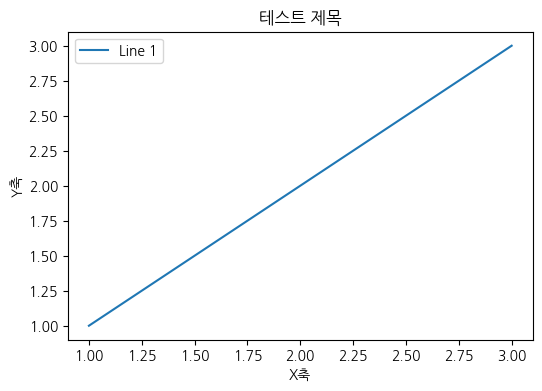

In [10]:
import matplotlib.pyplot as plt

# Set font to "NanumGothic"
plt.rcParams['font.family'] = "NanumGothic"

# Create a sample plot to check if the font is applied
plt.figure(figsize=(6, 4))
plt.plot([1, 2, 3], [1, 2, 3], label='Line 1')
plt.title('테스트 제목')  # Korean title to check font
plt.xlabel('X축')  # Korean label to check font
plt.ylabel('Y축')  # Korean label to check font
plt.legend()
plt.show()


In [4]:
import pandas as pd

df_kr = pd.read_csv('/Users/songsooyeoun/Desktop/git_test/streamlit/seoul_housing/data/seoul_real_estate.csv')
df_en = pd.read_csv('/Users/songsooyeoun/Desktop/git_test/streamlit/seoul_housing/data/seoul_real_estate_en.csv')

display(df_kr.head())
display(df_en.head())

,RCPT_YR,CGG_CD,CGG_NM,STDG_CD,STDG_NM,LOTNO_SE,LOTNO_SE_NM,MNO,SNO,BLDG_NM,...,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE,OPBIZ_RESTAGNT_SGG_NM
0,2025,11230,동대문구,10500,답십리동,1.0,대지,530.0,15.0,현대썬앤빌청계,...,12150,14.820,0.0000,9.0,NaN,NaN,2016.0,아파트,중개거래,서울 동대문구
1,2025,11650,서초구,10600,잠원동,1.0,대지,27.0,2.0,멀버리힐스,...,42000,21.863,32.9893,8.0,NaN,NaN,2022.0,오피스텔,중개거래,서울 서초구
2,2025,11530,구로구,10300,가리봉동,1.0,대지,137.0,4.0,삼부르네상스파크빌,...,40000,82.775,110.3780,7.0,NaN,NaN,2006.0,오피스텔,직거래,NaN
3,2025,11500,강서구,10700,외발산동,1.0,대지,216.0,37.0,가온빌,...,15000,23.730,20.0000,5.0,NaN,NaN,2016.0,연립다세대,직거래,NaN
4,2025,11620,관악구,10100,봉천동,1.0,대지,180.0,348.0,백조아트빌라,...,15000,57.950,25.0000,-1.0,NaN,NaN,1996.0,연립다세대,직거래,NaN


,RCPT_YR,CGG_CD,CGG_NM_EN,STDG_CD,STDG_NM,LOTNO_SE,LOTNO_SE_NM,MNO,SNO,CTRT_DAY,...,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE,OPBIZ_RESTAGNT_SGG_NM,CODE,BLDG_NM,CGG_NM
0,2025,11230,Dongdaemun-gu,10500,Dapsipni-dong,1.0,Land,530.0,15.0,2025-03-28,...,9.0,NaN,NaN,2016.0,Apartment,Brokerage Transaction,서울 동대문구,1123010500,Hyundai Sun & Ville Cheonggye,동대문구
1,2025,11650,Seocho-gu,10600,Jamwon-dong,1.0,Land,27.0,2.0,2025-03-28,...,8.0,NaN,NaN,2022.0,Officetel,Brokerage Transaction,서울 서초구,1165010600,Mulberry Hills,서초구
2,2025,11530,Guro-gu,10300,Garibong-dong,1.0,Land,137.0,4.0,2025-03-28,...,7.0,NaN,NaN,2006.0,Officetel,Direct Transaction,NaN,1153010300,Sambura Renaissance Parkville,구로구
3,2025,11500,Gangseo-gu,10700,Oebalsan-dong,1.0,Land,216.0,37.0,2025-03-28,...,5.0,NaN,NaN,2016.0,Multiplex House,Direct Transaction,NaN,1150010700,Gaon Bill,강서구
4,2025,11620,Gwanak-gu,10100,Bongcheon-dong,1.0,Land,180.0,348.0,2025-03-28,...,-1.0,NaN,NaN,1996.0,Multiplex House,Direct Transaction,NaN,1162010100,Swan Art Villa,관악구
